In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import os

# The shortcut acts as a direct directory path
dataset_path = '/content/drive/MyDrive/SEED_Dataset'

# Verify the files are accessible
print(os.listdir(dataset_path))

# Example: Load a specific file into a DataFrame
# df = pd.read_csv(f'{dataset_path}/training_data.csv')

['channel-order.xlsx', 'SEED_stimulation.xlsx', 'subject-id-gender-seed.txt', 'ExtractedFeatures_1s', 'ExtractedFeatures_4s', 'Preprocessed_EEG', 'SEED_RAW_EEG', 'SEED_website.txt']


Training on 36 files | Testing on 9 files

Loading data...
Scaling and applying PCA...
Training SVM Model...
Testing Model...

Accuracy: 65.17%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.59      0.55      0.57     10080
     Neutral       0.56      0.69      0.62      9936
    Positive       0.84      0.72      0.78     10530

    accuracy                           0.65     30546
   macro avg       0.66      0.65      0.65     30546
weighted avg       0.67      0.65      0.66     30546



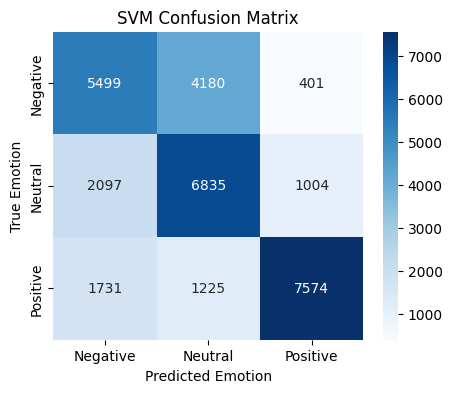

In [4]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- 1. Setup ---
path = "/content/drive/MyDrive/SEED_Dataset/ExtractedFeatures_1s"


raw_labels = [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1]
y_map = {-1: 0, 0: 1, 1: 2}
trial_labels = [y_map[lbl] for lbl in raw_labels]

# --- 2. Get Files and Split ---

all_files = [f for f in os.listdir(path) if f.endswith(".mat") and f != "label.mat"]
train_files, test_files = train_test_split(all_files, test_size=0.2, random_state=42)

print(f"Training on {len(train_files)} files | Testing on {len(test_files)} files")

# --- 3. Simple Data Extraction Function ---
def load_data(files):
    X, Y = [], []

    for f in files:
        mat = sio.loadmat(os.path.join(path, f))

        for i in range(15):
            key = f"de_LDS{i + 1}"

            if key in mat:

                data = np.transpose(mat[key], (1, 0, 2))
                n_samples = data.shape[0]


                X.append(data.reshape(n_samples, -1))
                Y.append(np.full(n_samples, trial_labels[i]))

    return np.vstack(X), np.concatenate(Y)

# --- 4. Load Train and Test Sets ---
print("\nLoading data...")
X_train, y_train = load_data(train_files)
X_test, y_test = load_data(test_files)

# --- 5. Scale and PCA ---
print("Scaling and applying PCA...")
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# --- 6. Train SVM ---
print("Training SVM Model...")
svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
svm.fit(X_train, y_train)

# --- 7. Evaluate and Plot ---
print("Testing Model...\n")
y_pred = svm.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Neutral", "Positive"]))

# Generate Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"])

plt.title("SVM Confusion Matrix")
plt.ylabel("True Emotion")
plt.xlabel("Predicted Emotion")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from scipy.stats import mode

# Assume y_pred is the output from your SVM
window_size = 5 # 5 seconds

# Smooth the predictions using a rolling window
smoothed_predictions = []
for i in range(len(y_pred)):
    # Look at a 5-second window around the current prediction
    start_idx = max(0, i - window_size // 2)
    end_idx = min(len(y_pred), i + window_size // 2 + 1)

    window = y_pred[start_idx:end_idx]

    # Replace the current prediction with the most common prediction in that window
    most_common = mode(window, keepdims=False)[0]
    smoothed_predictions.append(most_common)

# Check accuracy again using smoothed_predictions!